<a href="https://colab.research.google.com/github/oyueo-mm/OPTICS_by_entry/blob/main/OPTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**함수 세팅**

In [ ]:
import numpy as np

def get_dist(p1, p2):
    return np.linalg.norm(p1 - p2)

def get_core_dist(point_idx, X, eps, min_samples):
    # 현재 점 주변 eps 반경 내의 모든 이웃 탐색
    distances = [get_dist(X[point_idx], X[i]) for i in range(len(X))]
    neighbors = [i for i, d in enumerate(distances) if d <= eps]

    # 이웃 수가 min_samples보다 적으면 core이 아님
    if len(neighbors) < min_samples:
        return None

    # min_samples번째로 가까운 이웃까지의 거리가 가핵거리
    distances.sort()
    return distances[min_samples - 1]

In [ ]:
def update_seeds(seeds, core_dist, center_idx, X, processed, reachability_dists):
    # 중심점(center_idx)의 모든 이웃에 대해 계산
    for i in range(len(X)):
        if not processed[i]:
            new_reach_dist = max(core_dist, get_dist(X[center_idx], X[i]))

            # 처음 발견된 점이거나 더 짧은 경로를 찾았을 때 갱신
            if reachability_dists[i] is None or new_reach_dist < reachability_dists[i]:
                reachability_dists[i] = new_reach_dist
                # seeds엔 데이터의 인덱스가 들어감
                if i not in seeds:
                    seeds.append(i)

In [ ]:
def my_optics(X, eps, min_samples):
    processed = [False] * len(X)
    reachability_dists = [None] * len(X)
    ordered_list = []

    for i in range(len(X)):
        if not processed[i]:
            processed[i] = True
            ordered_list.append(i)

            core_dist = get_core_dist(i, X, eps, min_samples)

            if core_dist is not None:
                seeds = []
                update_seeds(seeds, core_dist, i, X, processed, reachability_dists)

                # 큐가 빌 때까지 반복 (가장 가까운 도달 거리부터 방문)
                while seeds:
                    seeds.sort(key=lambda x: reachability_dists[x])
                    # FIFO
                    current_node = seeds.pop(0)

                    processed[current_node] = True
                    ordered_list.append(current_node)

                    curr_core_dist = get_core_dist(current_node, X, eps, min_samples)
                    if curr_core_dist is not None:
                        update_seeds(seeds, curr_core_dist, current_node, X, processed, reachability_dists)

    return ordered_list, reachability_dists

**학습 시작**

In [ ]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=3, random_state = 1234)

eps = 10.0
min_samples = 10
ordered_indices, reachability_values = my_optics(X, eps, min_samples)

**시각화**

Text(0, 0.5, 'Reachability Distance')

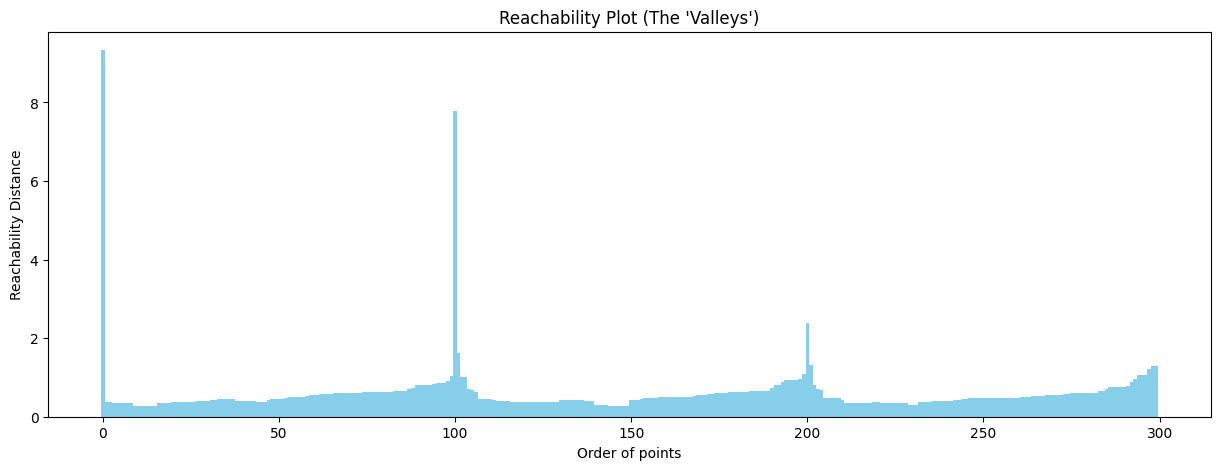

In [ ]:
plot_reachability = []
for i in ordered_indices:
    val = reachability_values[i]
    if (val == np.inf) or (val is None):
        plot_reachability.append(0) # 혹은 매우 큰 값
    else:
        plot_reachability.append(val)

# 시각화에서 0(무한대/노이즈)인 지점들을 눈에 띄게 만들기 위해 보정
max_val = max(plot_reachability)
plot_reachability = [x if x > 0 else max_val * 1.2 for x in plot_reachability]

plt.figure(figsize=(15, 5))

plt.bar(range(len(X)), plot_reachability, color='skyblue', width=1.0)
plt.title("Reachability Plot (The 'Valleys')")
plt.xlabel("Order of points")
plt.ylabel("Reachability Distance")